<a href="https://colab.research.google.com/github/SesSic/IAInvestigacionCurso/blob/main/sesion-06-ia-generativa/sesion06_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 6 — IA generativa para investigación y programación

**Temas:** diseño de prompts, asistencia para código, explicación de algoritmos, síntesis de información, validación y detección de errores

**Duración:** 3 horas

## 🎯 Antes de empezar, lo más importante de toda la sesión

**No necesitas saber programar para esta sesión.** La IA va a escribir el código por ti.

Tu trabajo no es memorizar sintaxis — es:
1. Pedirle claramente lo que necesitas (esto se llama "prompt")
2. Ejecutar el código que te da
3. **Verificar que el resultado tenga sentido** (esto es lo único que la IA no puede hacer por ti)

Si en las sesiones anteriores te costó el código, tranquilo — hoy la IA hace la parte técnica.

Tu criterio profesional (el que ya tienes de tu área) es lo que hace falta para revisar si la IA acertó o se equivocó.

## Objetivo de la sesión
- Escribir prompts efectivos para generar código y texto útil
- Comparar distintas herramientas de IA (gratis y de pago)
- Detectar errores en código generado por IA — la habilidad más importante de hoy
- Usar IA para una tarea real de tu trabajo docente: mejorar un sílabo

---## 🟦 Bloque 1 (50 min) — Tu primer prompt, sin salir de Colab

### 1.1 La forma más fácil de empezar: Gemini dentro de Colab

Google Colab tiene IA integrada gratis. Busca el ícono ✨ (ayuda de código con IA) que aparece cuando creas una celda nueva, o el botón "Generar" en la barra superior. No necesitas cuenta extra ni salir de esta pestaña.

**Prueba esto:** crea una celda de código nueva, haz clic en ✨, y escribe:

> "Crea un gráfico de barras con los promedios de nota_parcial1 agrupados por facultad, usando la variable datos"

*(Necesitas tener cargado tu dataset primero — usa el mismo código de la Sesión 5 si quieres, o pídele a la IA que te ayude a cargarlo también.)*

In [1]:
# Pega aquí el código que te generó Gemini/Colab AI
import pandas as pd
url = "https://raw.githubusercontent.com/SesSic/IAInvestigacionCurso/main/datasets/ejemplo_notas.csv"
datos = pd.read_csv(url)
datos.head()

,estudiante,facultad,grupo,nota_parcial1,nota_parcial2,asistencia_pct
0,Ana Torres,Ciencias Sociales,A,7.5,8.2,95
1,Luis Paredes,Ingeniería,A,6.8,7.0,80
2,Maria Chango,Ciencias Sociales,B,8.9,9.1,100
3,Carlos Vega,Educación,B,5.5,6.2,70
4,Sofia Ramos,Ingeniería,A,9.0,9.4,98


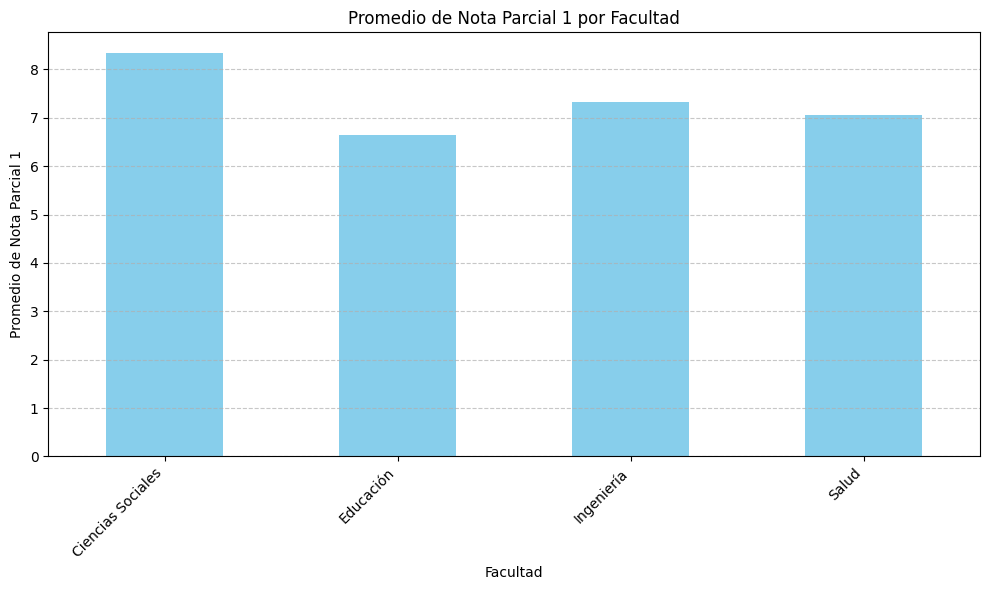

In [2]:
import matplotlib.pyplot as plt

promedio_por_facultad = datos.groupby('facultad')['nota_parcial1'].mean()

plt.figure(figsize=(10, 6))
promedio_por_facultad.plot(kind='bar', color='skyblue')
plt.title('Promedio de Nota Parcial 1 por Facultad')
plt.xlabel('Facultad')
plt.ylabel('Promedio de Nota Parcial 1')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.2 Anatomía de un buen prompt

Un prompt vago da resultados vagos.

Compara:
| Prompt débil | Prompt efectivo |
|---|---|
| "Hazme un gráfico" | "Crea un gráfico de barras que compare el promedio de nota_parcial1 por facultad, con título y ejes etiquetados en español" |
| "Analiza mis datos" | "Calcula el promedio, mediana y desviación estándar de la columna nota_parcial1, y dime si hay valores atípicos" |
| "Arregla mi código" | "Este código me da un error [pega el error exacto]. Aquí está el código: [pega el código]. ¿Qué está mal?" |

**La regla:** entre más específico seas (qué columna, qué tipo de gráfico, qué formato de salida), mejor el resultado — igual que le darías instrucciones claras a un asistente.

---### 🧪 Ejercicio 1 — Tu primer prompt efectivo

Escribe un prompt específico (no vago) pidiendo algo relacionado a tu propio dataset o tu propia área de trabajo. Pruébalo en el ✨ de Colab.

In [ ]:
# Pega aquí el código resultante de tu prompt

---## ☕ Descanso — 15 minutos

---## 🟩 Bloque 2 (50 min) — Comparando herramientas de IA

### 2.1 Opciones disponibles (todas tienen versión gratuita)

| Herramienta | Link | Nota |
|---|---|---|
| Gemini (dentro de Colab) | ya lo probaste arriba | El más cómodo, cero fricción |
| Claude | claude.ai | Buena versión gratuita, con límite de mensajes por día |
| ChatGPT | chatgpt.com | La más conocida, versión gratuita con límites |
| DeepSeek | chat.deepseek.com | Gratis, sin necesidad de tarjeta |Ninguna requiere pago para lo que vamos a hacer hoy.

### 2.2 Ejercicio comparativo

Copia este mismo prompt en **dos herramientas distintas** (por ejemplo Claude y DeepSeek) y compara las respuestas:

> "Explícame en 3 líneas, en lenguaje simple para alguien sin experiencia en programación, qué hace este código: `datos.groupby('grupo')['nota_parcial1'].mean()`"

Pega abajo lo que te respondió cada una (como texto, no como código).

**Respuesta de la Herramienta 1 (____________):***(pega aquí)*

**Respuesta de la Herramienta 2 (____________):***(pega aquí)*

### 2.3 ¿Notaste diferencias?
No todas las IA responden igual — varían en nivel de detalle, tono, y a veces hasta en si aciertan o no.

Por eso el paso de **verificar** nunca se salta, sin importar cuál uses.

---## ☕ Descanso — 15 minutos

---## 🟨 Bloque 3 (50 min) — Detectar errores + ejercicio de sílabo

### 3.1 El ejercicio más importante: encontrar el error

Aquí abajo hay código que "parece" correcto — se lo pedimos a una IA para calcular el promedio de aprobados (nota ≥ 7).

**Tiene un error sutil.** Ejecútalo y revisa si el resultado tiene sentido comparado con lo que tú ves en la tabla.

In [3]:
# Código con un error intencional para que lo detectes
aprobados = datos[datos["nota_parcial1"] > 7]  # pista: revisa el símbolo de comparación
porcentaje_aprobados = len(aprobados) / len(datos) * 100
print(f"Porcentaje de aprobados: {porcentaje_aprobados:.1f}%")

Porcentaje de aprobados: 53.3%


**Respuesta:** el código usa `> 7` (mayor estricto) en vez de `>= 7` (mayor o igual). Alguien con nota exactamente 7.0 quedaría excluido del conteo de aprobados, aunque sí aprobó. Es un error de un solo símbolo que cambia el resultado — exactamente el tipo de cosa que la IA puede pasar por alto y que **tu criterio profesional** debe atrapar.

In [4]:
aprobados_correcto = datos[datos["nota_parcial1"] >= 7]
porcentaje_correcto = len(aprobados_correcto) / len(datos) * 100
print(f"Porcentaje de aprobados (corregido): {porcentaje_correcto:.1f}%")

Porcentaje de aprobados (corregido): 60.0%


### 3.2 Ejercicio final: mejora un sílabo con IA

Esta parte no usa código — es puro prompt, y aplica a tu trabajo real como docente esta misma semana.

**Prompt sugerido (cópialo y ajústalo con los datos reales de tu asignatura):**

> "Actúa como asesor pedagógico. Tengo una asignatura de [nombre de tu materia] para estudiantes de [nivel/semestre]. Ayúdame a redactar 3 resultados de aprendizaje claros y medibles para esta asignatura, alineados con el enfoque de [breve descripción de tu enfoque o contenido principal]. Hazlo en español, en formato de lista."

> "Tengo este Silabo que genere de una materia anterior, Actúa como asesor pedagógico. Tengo una asignatura de [nombre de tu materia] para estudiantes de [nivel/semestre]. Ayúdame a redactar 3 resultados de aprendizaje claros y medibles para esta asignatura, alineados con el enfoque de [breve descripción de tu enfoque o contenido principal]. Hazlo en español, en el mismo formato del archivo que te envíe y generame uno nuevo con los nuevos contenidos"

**Pega aquí lo que te generó la IA sobre tu sílabo:***(pega aquí)*

In [5]:
import pandas as pd

# Resultados de aprendizaje
learning_outcomes = [
    "El estudiante será capaz de resolver ecuaciones y sistemas de ecuaciones lineales y cuadráticas, aplicando los métodos y propiedades fundamentales del álgebra presentados en 'Álgebra de Baldor', demostrando precisión en los cálculos.",
    "El estudiante podrá identificar y aplicar las razones trigonométricas (seno, coseno, tangente) en triángulos rectángulos y en el círculo unitario para resolver problemas geométricos y de aplicación básica, interpretando correctamente los resultados.",
    "El estudiante resolverá identidades y ecuaciones trigonométricas básicas, demostrando comprensión de las relaciones fundamentales entre las funciones trigonométricas y justificando cada paso de la solución."
]

# Crear un DataFrame
df_outcomes = pd.DataFrame(learning_outcomes, columns=['Resultados de Aprendizaje'])

# Guardar en un archivo Excel
excel_filename = 'resultados_aprendizaje_matematicas.xlsx'
df_outcomes.to_excel(excel_filename, index=False)

print(f"Se ha creado el archivo '{excel_filename}' con los resultados de aprendizaje.")

Se ha creado el archivo 'resultados_aprendizaje_matematicas.xlsx' con los resultados de aprendizaje.


### ⚠️ Verificación obligatoria antes de usar esto en tu sílabo real

Antes de copiar cualquier resultado de IA a un documento oficial, revisa:
- [ ] ¿Los resultados de aprendizaje coinciden con el formato que exige tu universidad?
- [ ] ¿La bibliografía sugerida (si pediste alguna) existe realmente? Búscala para confirmar — la IA a veces inventa referencias
- [ ] ¿El contenido refleja lo que tú realmente enseñas, o suena genérico?
- [ ] ¿Necesita ajustes de terminología específica de tu área?

**La IA te da un primer borrador rápido — la versión final siempre la valida tu criterio de experto en la materia.**

---## ✅ Cierre de la sesión
Hoy lograste:
- ✅ Confirmar que puedes usar IA para generar código útil sin saber programar de memoria
- ✅ Escribir prompts específicos en vez de vagos
- ✅ Comparar respuestas entre distintas herramientas de IA
- ✅ Detectar un error real en código generado por IA
- ✅ Usar IA para un borrador de sílabo, con checklist de verificación

**Mensaje clave para llevarte:** la IA te ahorra tiempo escribiendo el código o el texto. Tu trabajo, en cualquier área, es siempre el mismo: **verificar que el resultado sea correcto antes de usarlo.**

**Para la próxima sesión (Revisión de literatura):** vamos a aplicar este mismo principio de "generar con IA + verificar" a la búsqueda y síntesis de papers académicos.

📎 Recuerda: `Archivo → Guardar una copia en Drive` para no perder tu trabajo.